(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


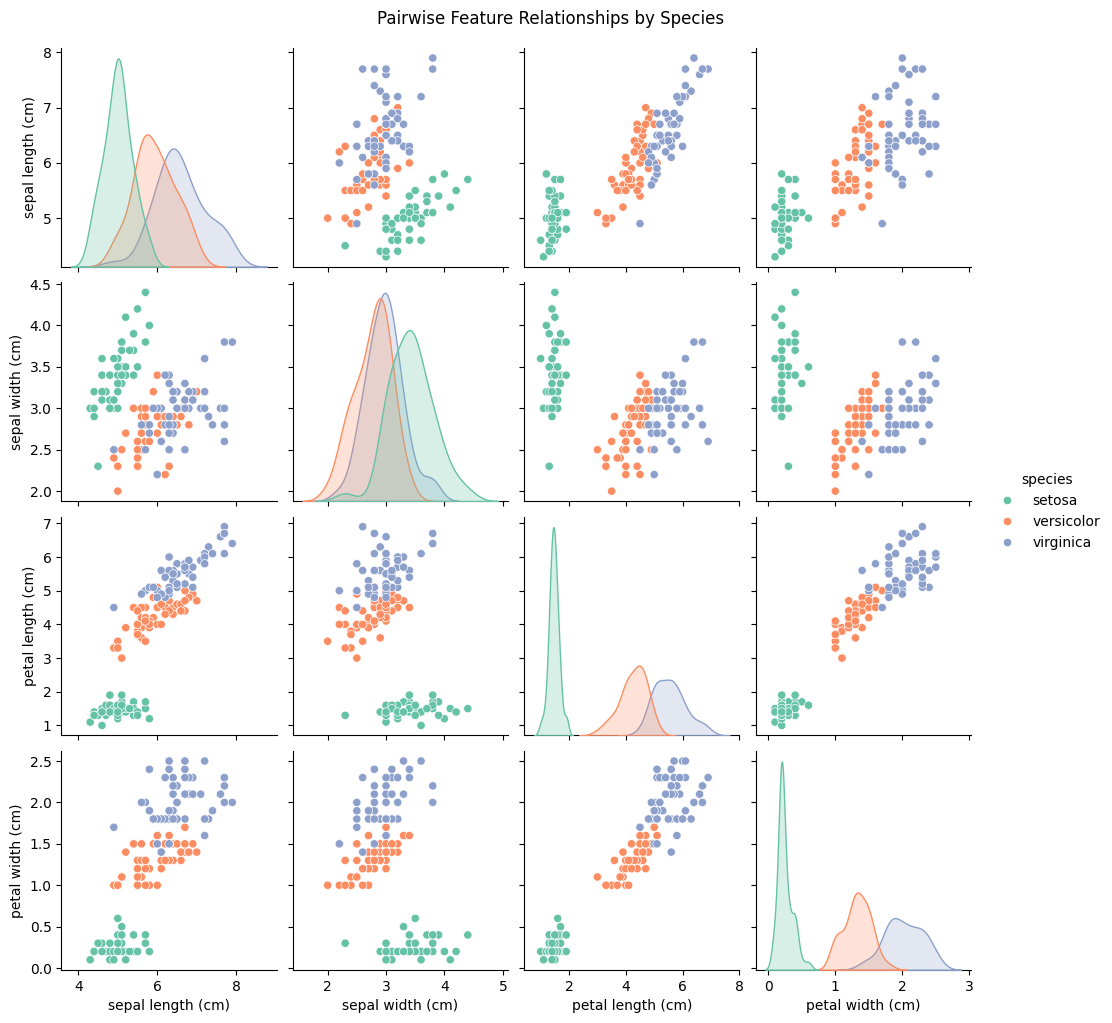

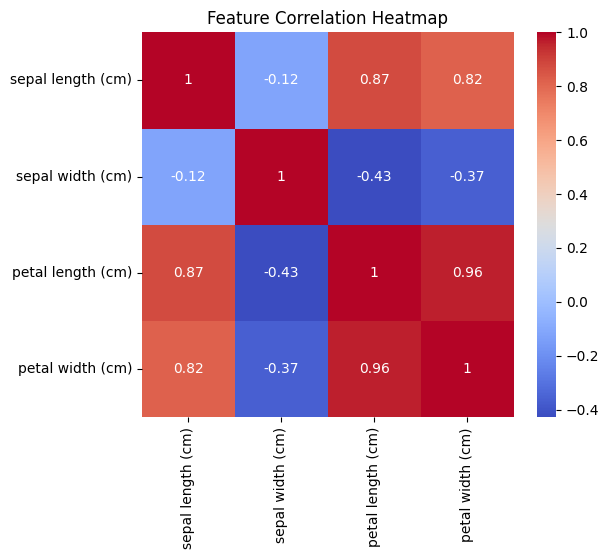

Train size: 120  Test size: 30
Logistic Regression: 0.9667 accuracy
Decision Tree: 0.9333 accuracy
K-Nearest Neighbors: 1.0000 accuracy
Best model: K-Nearest Neighbors with accuracy 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



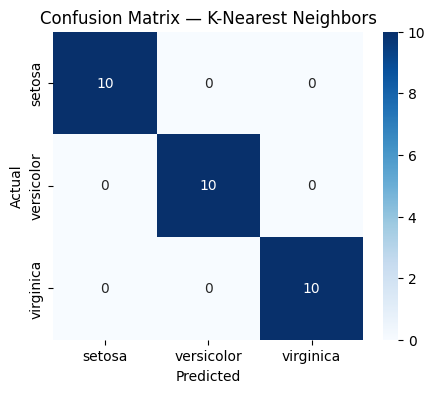

Model saved as iris_model.pkl


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
print(df.shape)
df.head()
df.info()
df.describe()
df['species'].value_counts()
sns.pairplot(df, hue='species', palette='Set2')
plt.suptitle('Pairwise Feature Relationships by Species', y=1.02)
plt.show()
plt.figure(figsize=(6,5))
sns.heatmap(df.drop(columns='species').corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()
X = df[iris.feature_names]
y = df['species']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc:.4f} accuracy")
best_name = max(results, key=results.get)
best_model = models[best_name]
print("Best model:", best_name, "with accuracy", results[best_name])
preds = best_model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, preds))
cm = confusion_matrix(y_test, preds, labels=iris.target_names)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()
with open('iris_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model saved as iris_model.pkl")